# ARBOL DE DECISIÓN MULTICLASE
## FUENTE : [kaggle](https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elikplim/car-evaluation-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-evaluation-data-set' dataset.
Path to dataset files: /kaggle/input/car-evaluation-data-set


In [3]:
!ls /kaggle/input/car-evaluation-data-set

car_evaluation.csv


In [4]:
PATH_CSV = path + '/car_evaluation.csv'

In [5]:
df_car = pd.read_csv(PATH_CSV,header=None)
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df_car.columns = col_names
df_car

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [7]:
df_car.dtypes

,0
buying,object
maint,object
doors,object
persons,object
lug_boot,object
safety,object
class,object


In [6]:
df_car['doors'].value_counts()

,count
doors,
2,432
3,432
4,432
5more,432


In [8]:
df_car['doors'] = df_car['doors'].replace('5more',5)
df_car['doors'].value_counts()

,count
doors,
2,432
3,432
4,432
5,432


In [9]:
df_car = df_car.drop('persons',axis=1)
df_car

,buying,maint,doors,lug_boot,safety,class
0,vhigh,vhigh,2,small,low,unacc
1,vhigh,vhigh,2,small,med,unacc
2,vhigh,vhigh,2,small,high,unacc
3,vhigh,vhigh,2,med,low,unacc
4,vhigh,vhigh,2,med,med,unacc
...,...,...,...,...,...,...
1723,low,low,5,med,med,good
1724,low,low,5,med,high,vgood
1725,low,low,5,big,low,unacc
1726,low,low,5,big,med,good


# EDA

In [10]:
df_car.dtypes

,0
buying,object
maint,object
doors,object
lug_boot,object
safety,object
class,object


In [11]:
df_car.isnull().sum()

,0
buying,0
maint,0
doors,0
lug_boot,0
safety,0
class,0


In [12]:
df_car['doors'] = df_car['doors'].astype(int)
df_car.dtypes

,0
buying,object
maint,object
doors,int64
lug_boot,object
safety,object
class,object


# CODIFICACIÓN DE VARIABLES CATEGORICAS CON CATEGORY-ENCODERS

In [13]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 992.9 kB/s eta 0:00:00


In [14]:
df_car.columns

Index(['buying', 'maint', 'doors', 'lug_boot', 'safety', 'class'], dtype='object')

In [15]:
import category_encoders as ce

encoder = ce.OrdinalEncoder(cols=['buying', 'maint','lug_boot', 'safety', 'class'])
df_car_encoder = encoder.fit_transform(df_car)
df_car_encoder

,buying,maint,doors,lug_boot,safety,class
0,1,1,2,1,1,1
1,1,1,2,1,2,1
2,1,1,2,1,3,1
3,1,1,2,2,1,1
4,1,1,2,2,2,1
...,...,...,...,...,...,...
1723,4,4,5,2,2,4
1724,4,4,5,2,3,3
1725,4,4,5,3,1,1
1726,4,4,5,3,2,4


In [16]:
df_car_encoder.dtypes

,0
buying,int64
maint,int64
doors,int64
lug_boot,int64
safety,int64
class,int64


In [17]:
df_car['class'].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


# ENTRENAMIENTO DEL MODELO DE ARBOL DE DECISIÓN MULTICLASE

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# PASO 1 - DEFINIMOS VARIABLE X Y Y

In [19]:
X = df_car_encoder.drop(['class'], axis=1)
y = df_car_encoder['class']

# PASO 2 - DIVIDIR DATASET EN TRAIN Y TEST

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, random_state = 42, stratify=y)

# PASO 3 - APLICAMOS DecisionTreeClassifier

In [21]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Exactitud del modelo: {accuracy}')

Exactitud del modelo: 0.6127167630057804


In [23]:
df_car['class'].unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

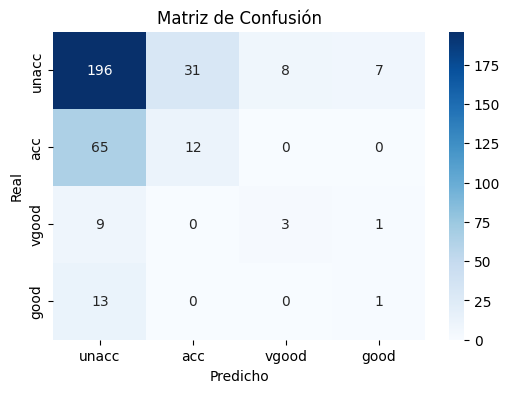

In [24]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['unacc', 'acc', 'vgood', 'good'], yticklabels=['unacc', 'acc', 'vgood', 'good'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()